In [7]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

### 240719

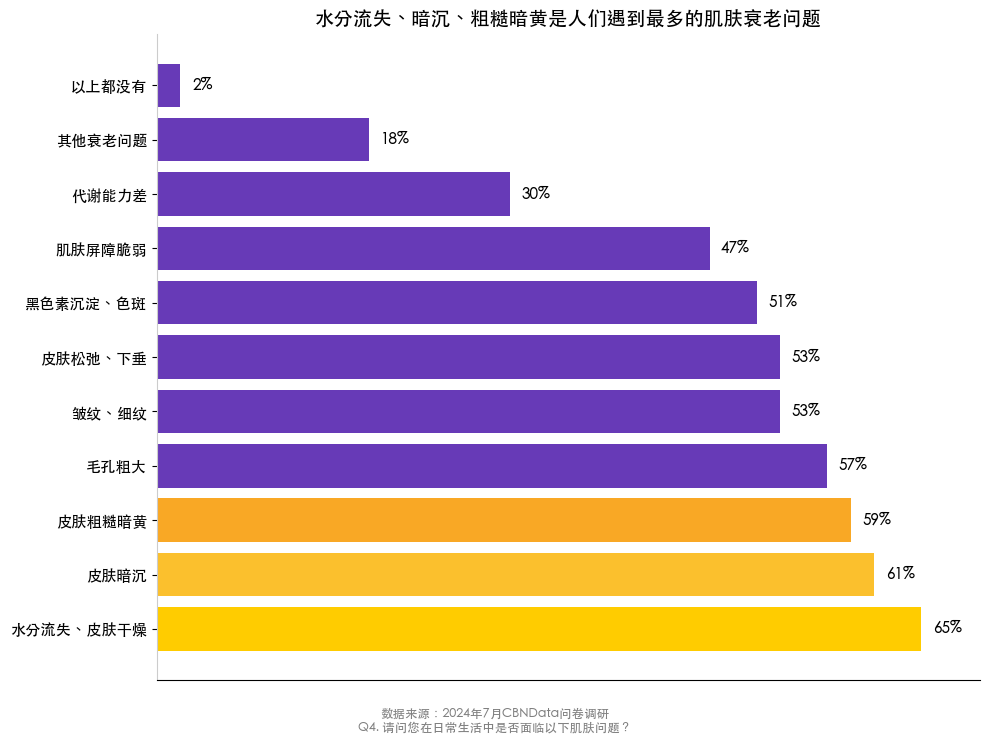

In [8]:
import matplotlib.pyplot as plt

# 设置问题与百分比（按原图顺序，从高到低）
labels = [
    '水分流失、皮肤干燥',
    '皮肤暗沉',
    '皮肤粗糙暗黄',
    '毛孔粗大',
    '皱纹、细纹',
    '皮肤松弛、下垂',
    '黑色素沉淀、色斑',
    '肌肤屏障脆弱',
    '代谢能力差',
    '其他衰老问题',
    '以上都没有'
]
percentages = [65, 61, 59, 57, 53, 53, 51, 47, 30, 18, 2]

# 颜色定义（前3个高亮金黄，其余统一紫色）
colors = ['#FFCC00', '#FBC02D', '#F9A825'] + ['#673AB7'] * (len(labels) - 3)

# 反转顺序：从上到下显示最高到最低
labels = labels[::-1]
percentages = percentages[::-1]
colors = colors[::-1]
y_pos = range(len(labels))

# 创建图形
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(y_pos, percentages, color=colors)

# 添加百分比标签
for bar, pct in zip(bars, percentages):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=11)

# 图表样式设置
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.invert_yaxis()  # 最大值在上
ax.set_xlim(0, 70)
ax.set_title("水分流失、暗沉、粗糙暗黄是人们遇到最多的肌肤衰老问题", fontsize=14, weight='bold')

# 去除边框和多余坐标
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.xaxis.set_visible(False)

# 数据来源标注
source_text = (
    "数据来源：2024年7月CBNData问卷调研\n"
    "Q4. 请问您在日常生活中是否面临以下肌肤问题？"
)
plt.figtext(0.5, -0.05, source_text, wrap=True, ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()



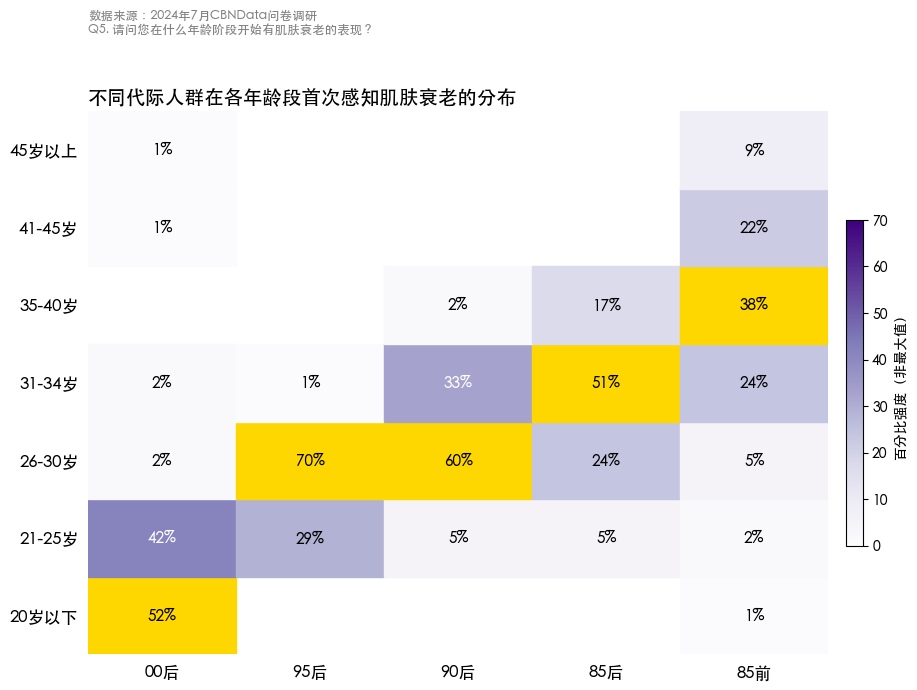

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 行列标签
age_groups = ['20岁以下', '21-25岁', '26-30岁', '31-34岁', '35-40岁', '41-45岁', '45岁以上']
generations = ['00后', '95后', '90后', '85后', '85前']

# 百分比矩阵
percent_data = np.array([
    [52, 0, 0, 0, 1],
    [42, 29, 5, 5, 2],
    [2, 70, 60, 24, 5],
    [2, 1, 33, 51, 24],
    [0, 0, 2, 17, 38],
    [1, 0, 0, 0, 22],
    [1, 0, 0, 0, 9],
])

# 计算每列最大值位置（用于黄色高亮）
highlight_mask = (percent_data == np.max(percent_data, axis=0))

# 颜色映射
cmap = plt.cm.Purples
norm = mcolors.Normalize(vmin=0, vmax=np.max(percent_data))

# 图像准备
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, len(generations))
ax.set_ylim(0, len(age_groups))

# 绘制单元格
for i in range(len(age_groups)):
    for j in range(len(generations)):
        value = percent_data[i, j]
        if value > 0:
            if highlight_mask[i, j]:
                color = '#FFD700'  # 黄色高亮最大值
                text_color = 'black'
            else:
                color = cmap(norm(value))  # 紫色热力
                text_color = 'white' if value > 30 else 'black'
            ax.add_patch(plt.Rectangle((j, len(age_groups)-1-i), 1, 1, color=color))
            ax.text(j + 0.5, len(age_groups)-1-i + 0.5, f'{value}%',
                    ha='center', va='center', fontsize=11, color=text_color)

# 设置轴标签
ax.set_xticks(np.arange(len(generations)) + 0.5)
ax.set_xticklabels(generations, fontsize=12)
ax.set_yticks(np.arange(len(age_groups)) + 0.5)
ax.set_yticklabels(age_groups[::-1], fontsize=12)
ax.invert_yaxis()

# 标题与数据来源
plt.title('不同代际人群在各年龄段首次感知肌肤衰老的分布', fontsize=14, weight='bold', loc='left')
plt.text(0, -1, '数据来源：2024年7月CBNData问卷调研\nQ5. 请问您在什么年龄阶段开始有肌肤衰老的表现？',
         fontsize=9, color='gray')

# 样式清理
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False)
plt.grid(False)

# 添加颜色条（只显示紫色映射）
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                    ax=ax, orientation='vertical', shrink=0.6, pad=0.02)
cbar.set_label('百分比强度（非最大值）', fontsize=10)

plt.tight_layout()
plt.show()


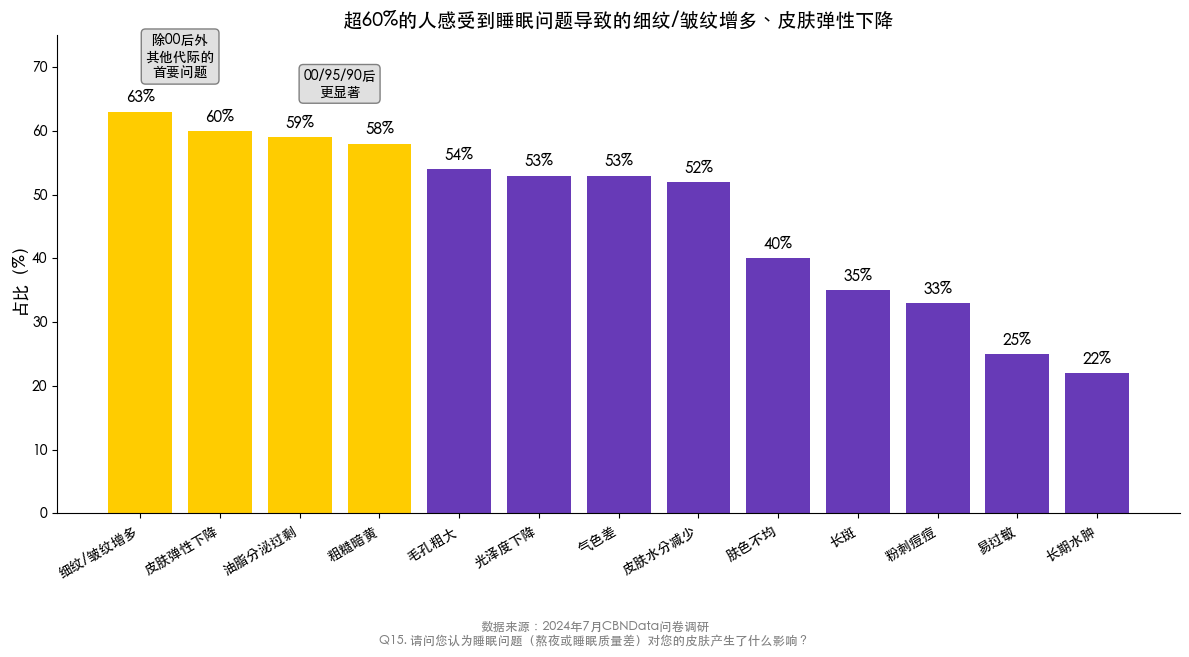

In [10]:
import matplotlib.pyplot as plt

# 数据
labels = [
    '细纹/皱纹增多', '皮肤弹性下降', '油脂分泌过剩', '粗糙暗黄', '毛孔粗大', '光泽度下降',
    '气色差', '皮肤水分减少', '肤色不均', '长斑', '粉刺痘痘', '易过敏', '长期水肿'
]
percentages = [63, 60, 59, 58, 54, 53, 53, 52, 40, 35, 33, 25, 22]

# 设置颜色
colors = ['#FFCC00' if i < 4 else '#673AB7' for i in range(len(labels))]

x = range(len(labels))
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(x, percentages, color=colors)

# 添加柱上的百分比标签
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1,
            f'{percentages[i]}%', ha='center', va='bottom', fontsize=11)

# 设置x轴标签
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10, rotation=30, ha='right')

# 标题
ax.set_title('超60%的人感受到睡眠问题导致的细纹/皱纹增多、皮肤弹性下降',
             fontsize=14, weight='bold')

ax.set_ylim(0, 75)
ax.set_ylabel('占比（%）', fontsize=12)

# ✅ 修正标签1：横跨前两列
mid_x = (0 + 1) / 2
ax.text(mid_x, 68, '除00后外\n其他代际的\n首要问题',
        ha='center', va='bottom', fontsize=10,
        bbox=dict(facecolor='#E0E0E0', edgecolor='gray', boxstyle='round,pad=0.3'))

# ✅ 标签2：00/95/90后更显著（保持不变）
ax.text(2.5, 65, '00/95/90后\n更显著',
        ha='center', va='bottom', fontsize=10,
        bbox=dict(facecolor='#E0E0E0', edgecolor='gray', boxstyle='round,pad=0.3'))

# 数据来源脚注
plt.figtext(0.5, -0.08,
            '数据来源：2024年7月CBNData问卷调研\nQ15. 请问您认为睡眠问题（熬夜或睡眠质量差）对您的皮肤产生了什么影响？',
            wrap=True, ha='center', fontsize=9, color='gray')

# 美化
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', left=True)

plt.tight_layout()
plt.show()


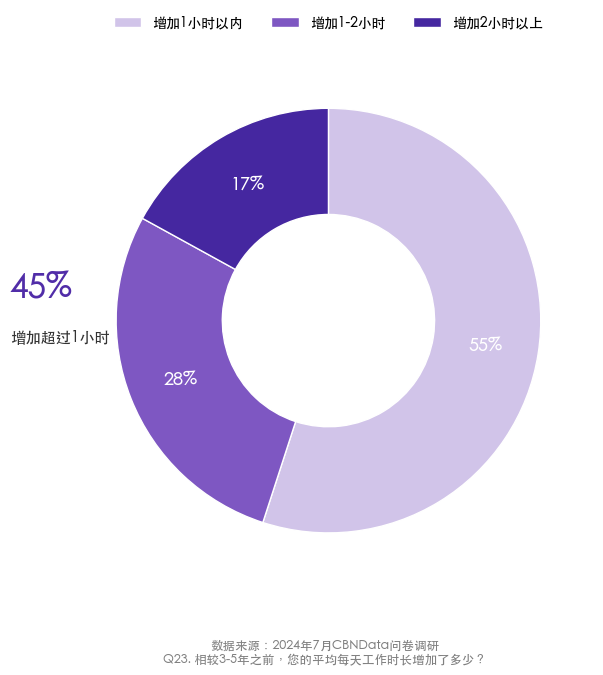

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib


# 数据
labels = ['增加1小时以内', '增加1-2小时', '增加2小时以上']
sizes = [55, 28, 17]
colors = ['#D1C4E9', '#7E57C2', '#4527A0']

# 创建图形
fig, ax = plt.subplots(figsize=(7, 6))

# 绘制饼图，使用 autopct 自动显示比例并居中显示
wedges, texts, autotexts = ax.pie(
    sizes,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.5, edgecolor='white'),
    autopct='%1.0f%%',
    pctdistance=0.75
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')

# 左侧文字
ax.text(-1.5, 0.1, '45%', fontsize=24, fontweight='bold', color='#512DA8')
ax.text(-1.5, -0.1, '增加超过1小时', fontsize=11, color='#333333')

# 图例
ax.legend(wedges, labels, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3, frameon=False, fontsize=10)

# 数据来源
plt.figtext(
    0.5, -0.1,
    "数据来源：2024年7月CBNData问卷调研\nQ23. 相较3-5年之前，您的平均每天工作时长增加了多少？",
    wrap=True, ha='center', fontsize=9, color='gray'
)

plt.tight_layout()
plt.show()
